<span style='font-size:40px; display:block;'>
<b>
    Ustar filtering
</b>
</br>

---

# **BACKGROUND**

---

Filtering NEE, FN2O and FCH4 using the seasonal ustar thresholds detected with ReddyProc.
The purpose is to exclude fluxes calculated in periods with insufficient turbulence, thus avoiding biases in fluxes.

---

# **IMPORTS**

---

In [4]:
import importlib.metadata
import warnings
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


---

# **LOAD DATA**

---

In [5]:
FILEPATH = r"61.1_FLUXES_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"
maindf = load_parquet(filepath=FILEPATH)
maindf

Loaded .parquet file 61.1_FLUXES_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.516 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FCH4_L3.1_L3.2_QCF0,Ustar_U16_Thres_reddyproc,Ustar_U50_Thres_reddyproc,Ustar_U84_Thres_reddyproc,NEE_U16_f_reddyproc,NEE_U50_f_reddyproc,NEE_U84_f_reddyproc,GPP_U16_f_reddyproc,GPP_U50_f_reddyproc,GPP_U84_f_reddyproc,Reco_U16_reddyproc,Reco_U50_reddyproc,Reco_U84_reddyproc,LE_f_reddyproc,H_f_reddyproc
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,1009.65,1.18057,0.024459,1191.96,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,NaN,0.078656,0.107971,0.135955,1.305666,1.386538,1.386538,0.718624,0.611666,0.672666,2.024290,1.998204,2.059205,26.496383,-11.217375
2023-11-07 16:15:00,1009.74,1.18107,0.024448,1192.57,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,NaN,0.078656,0.107971,0.135955,1.629891,1.626907,1.630082,0.385421,0.362524,0.420471,2.015312,1.989431,2.050553,25.297519,-13.000232
2023-11-07 16:45:00,1009.93,1.18176,0.024430,1193.50,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,NaN,0.078656,0.107971,0.135955,2.182820,2.243839,2.271905,-0.185413,-0.271904,-0.238610,1.997407,1.971935,2.033295,16.279850,-1.975767
2023-11-07 17:15:00,1009.97,1.18428,0.024377,1196.09,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,2.488800,0.078656,0.107971,0.135955,2.185734,2.238244,2.320900,-0.263635,-0.339915,-0.360285,1.922099,1.898329,1.960615,13.569823,-11.683789
2023-11-07 17:45:00,1010.06,1.18448,0.024372,1196.40,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,-9.177059,0.078656,0.107971,0.135955,2.179315,2.233295,2.318861,-0.252822,-0.330670,-0.354001,1.926493,1.902625,1.964860,13.913214,-10.829124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,2.160966,0.071409,0.092554,0.130809,10.095010,10.095010,10.095010,-1.623879,-1.088879,-1.044891,8.471131,9.006131,9.050119,3.778325,-38.997547
2025-06-04 23:15:00,1014.04,1.14156,0.025222,1157.59,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.071409,0.092554,0.130809,8.641342,8.641342,8.641342,-0.191333,0.342560,0.387403,8.450008,8.983902,9.028745,-0.947239,-39.849475
2025-06-04 23:45:00,1013.47,1.14369,0.025185,1159.10,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.071409,0.092554,0.130809,8.664543,8.664543,8.664543,-0.331079,0.196702,0.246219,8.333464,8.861245,8.910762,2.365148,-53.513862


## Select the variables we are interested in

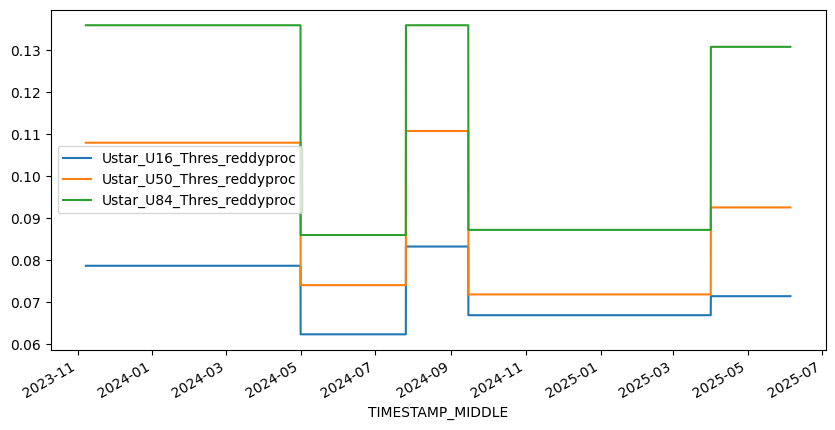

In [6]:
USTAR_SCENARIOS = ['Ustar_U16_Thres_reddyproc', 'Ustar_U50_Thres_reddyproc', 'Ustar_U84_Thres_reddyproc']
maindf[USTAR_SCENARIOS].plot(x_compat=True, figsize=(10, 5));

In [7]:
FLUX_VARS = [c for c in maindf.columns if 'L3.1_L3.2' in c]
TO_BE_FILTERED = ['NEE', 'FN2O', 'FCH4']
VARS_TO_FILTER = [c for c in FLUX_VARS if c.startswith(tuple(TO_BE_FILTERED))]
maindf[VARS_TO_FILTER]

,NEE_L3.1_L3.2_QCF,NEE_L3.1_L3.2_QCF0,FN2O_L3.1_L3.2_QCF,FN2O_L3.1_L3.2_QCF0,FCH4_L3.1_L3.2_QCF,FCH4_L3.1_L3.2_QCF0
TIMESTAMP_MIDDLE,,,,,,
2023-11-07 15:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-07 16:15:00,NaN,NaN,0.324973,0.324973,-4.360399,NaN
2023-11-07 16:45:00,NaN,NaN,0.053551,0.053551,NaN,NaN
2023-11-07 17:15:00,NaN,NaN,0.339963,0.339963,2.488800,2.488800
2023-11-07 17:45:00,NaN,NaN,-0.983566,-0.983566,-9.177059,-9.177059
...,...,...,...,...,...,...
2025-06-04 22:45:00,10.095010,10.095010,-0.069384,-0.069384,2.160966,2.160966
2025-06-04 23:15:00,8.641342,8.641342,-0.288296,-0.288296,-1.904577,NaN
2025-06-04 23:45:00,8.664543,8.664543,0.220511,0.220511,NaN,NaN


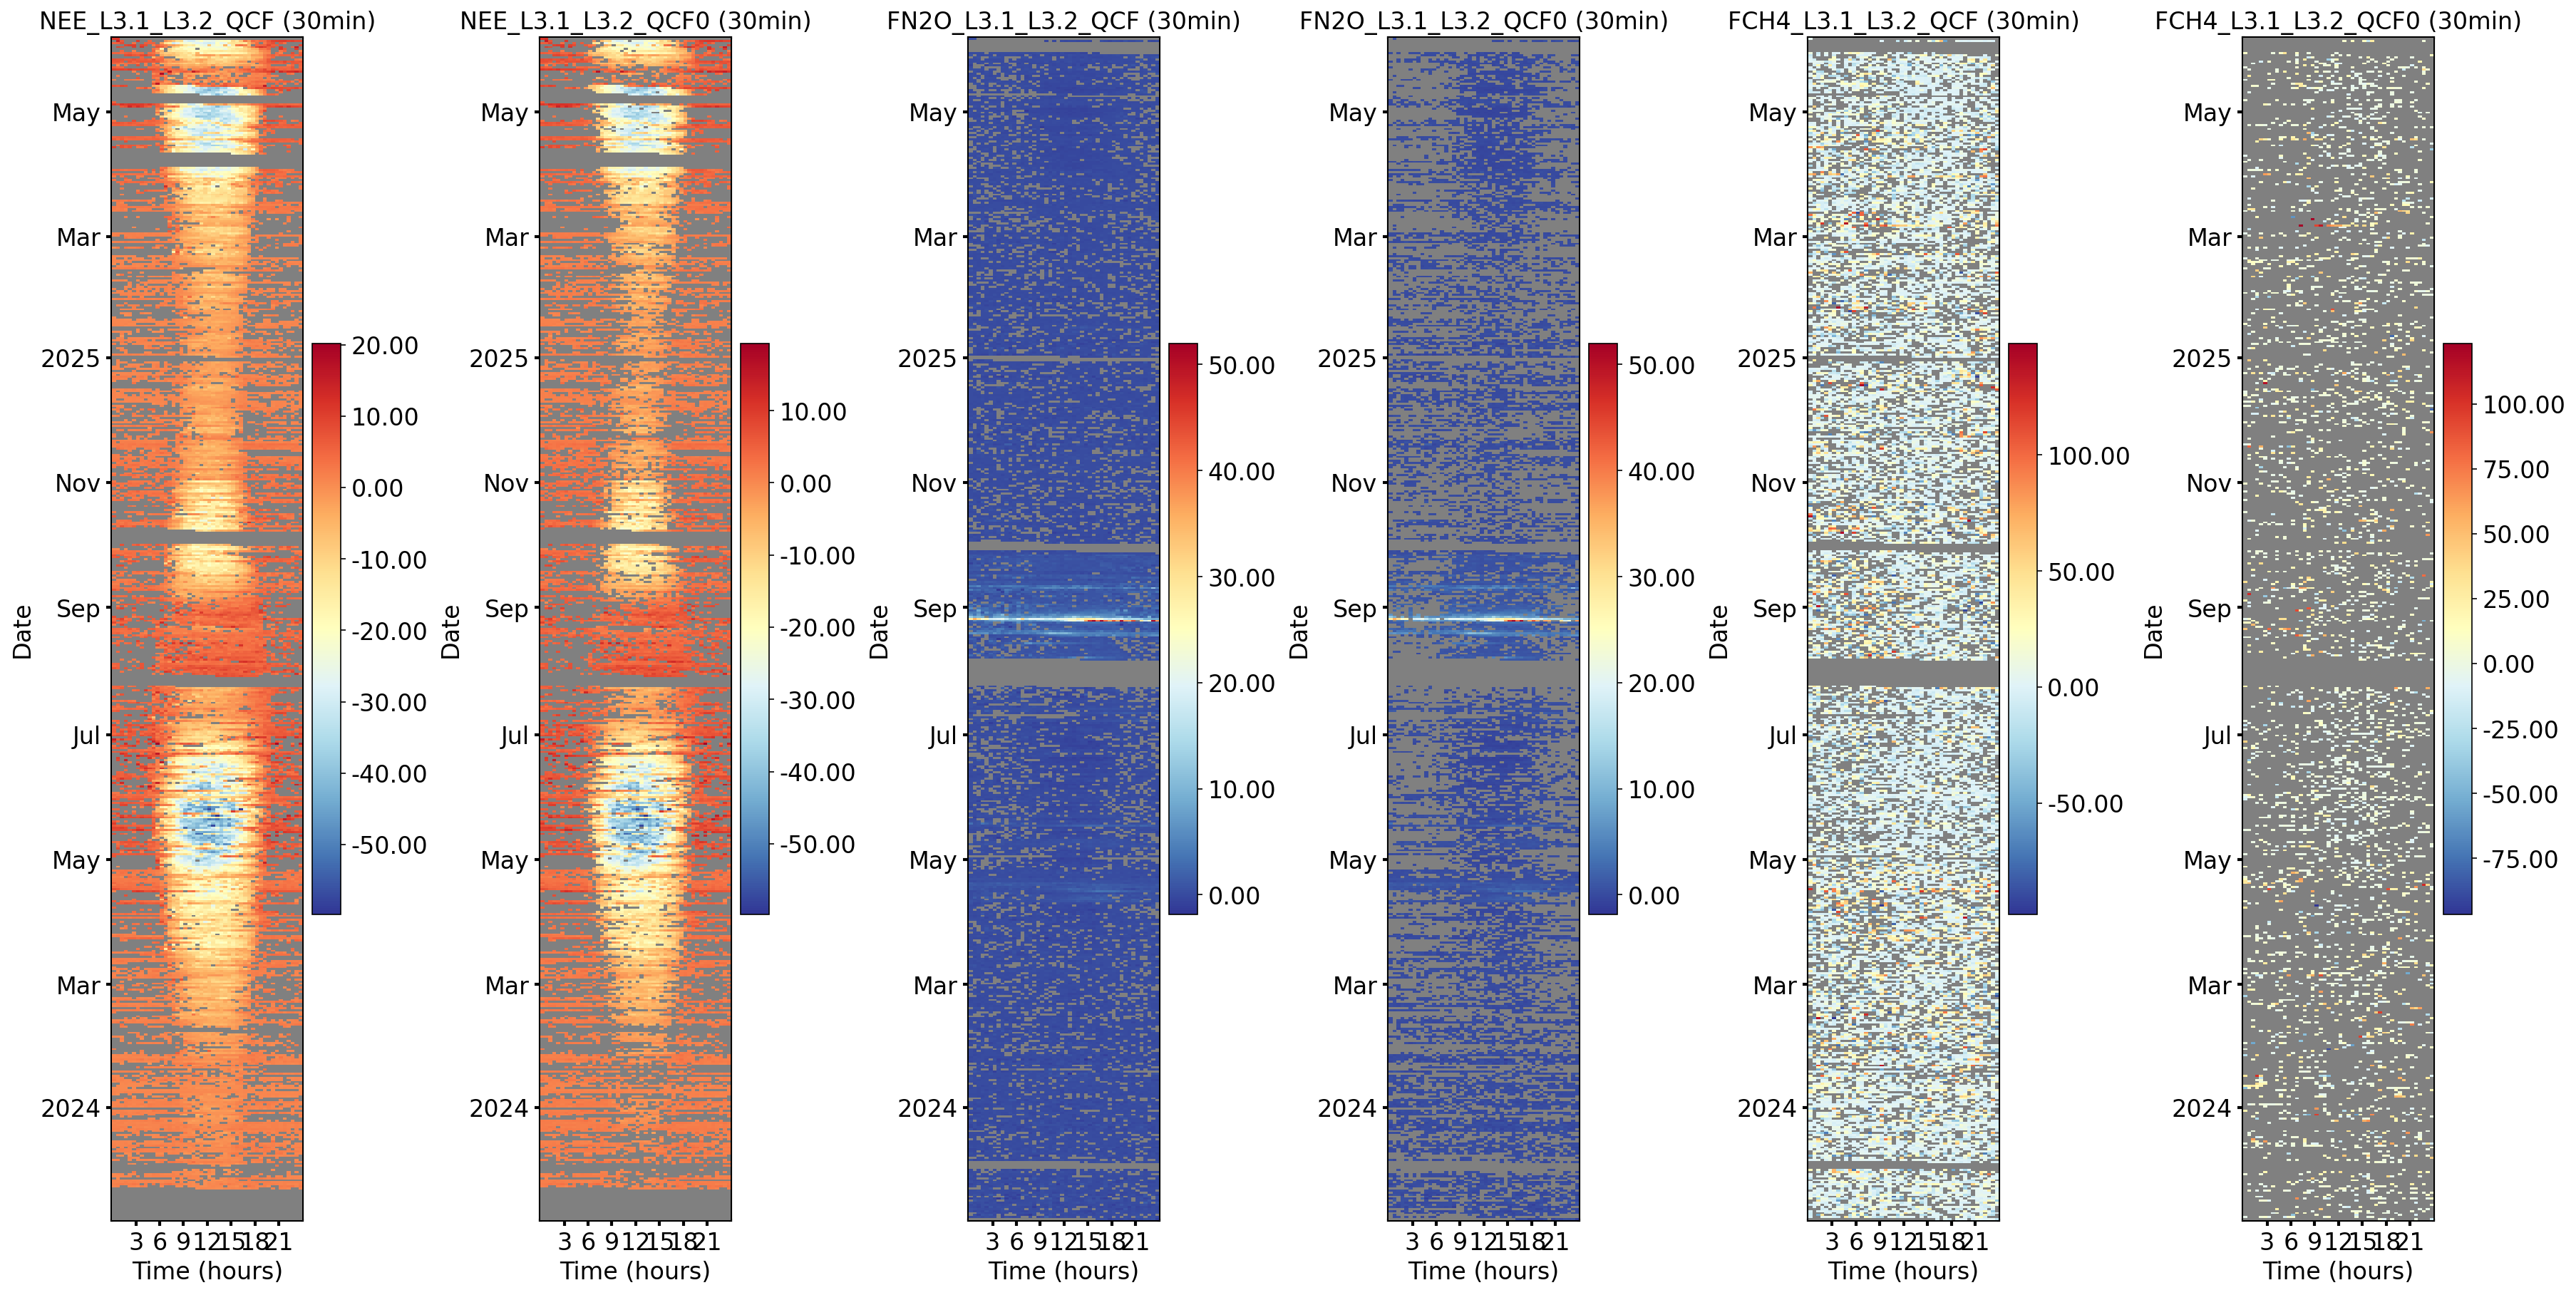

In [8]:
# Plot the fluxes that will be filtered

fig, axs = plt.subplots(ncols=6, nrows=1, figsize=(24, 12), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, VARS_TO_FILTER):
    HeatmapDateTime(series=maindf[var], ax=ax).plot()

</br>

</br>

---

# **USTAR FILTERING**

---

In [9]:
df_new = maindf.copy()

for var in VARS_TO_FILTER:
    n_total = df_new[var].notna().sum()   # valid values in original variable
    for cut in USTAR_SCENARIOS:
        CUT = cut[7:9]
        name_var = f"{var.split('_', 1)[0]}_L3.3_CUT_{CUT}_{var.rsplit('_', 1)[-1]}"
        name_flag = f"FLAG_L3.3_CUT_{CUT}_{var.split('_', 1)[0]}_L3.2_{var.rsplit('_', 1)[-1]}_USTAR_TEST"
        # Initialize if new
        if name_var not in df_new:
            df_new[name_var] = np.nan
        if name_flag not in df_new:
            df_new[name_flag] = 0.0
        valid_mask = df_new[var].notna()
        mask = df_new["USTAR"] > df_new[cut]
        df_new.loc[mask & valid_mask, name_var]  = df_new.loc[mask, var]
        df_new.loc[~mask & valid_mask, name_flag] = 2.0
        # Print stats
        n_out = (df_new[name_flag] == 2.0).sum()
        pct   = 100 * n_out / n_total if n_total > 0 else np.nan
        print(f"USTAR threshold CUT_{int(CUT)} removed "
              f"{n_out} values, {pct:.1f}% of {var}")

USTAR threshold CUT_16 removed 1755 values, 10.2% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 2749 values, 15.9% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 4099 values, 23.7% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 1313 values, 8.8% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 2079 values, 13.9% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 3163 values, 21.1% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 3313 values, 15.5% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 4920 values, 23.0% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 6870 values, 32.1% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 1128 values, 9.1% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 1753 values, 14.1% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 2597 values, 20.9% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 2720 values, 16.4% of FCH4_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 4035 values, 24.4% of FCH4_L3.1_L3.

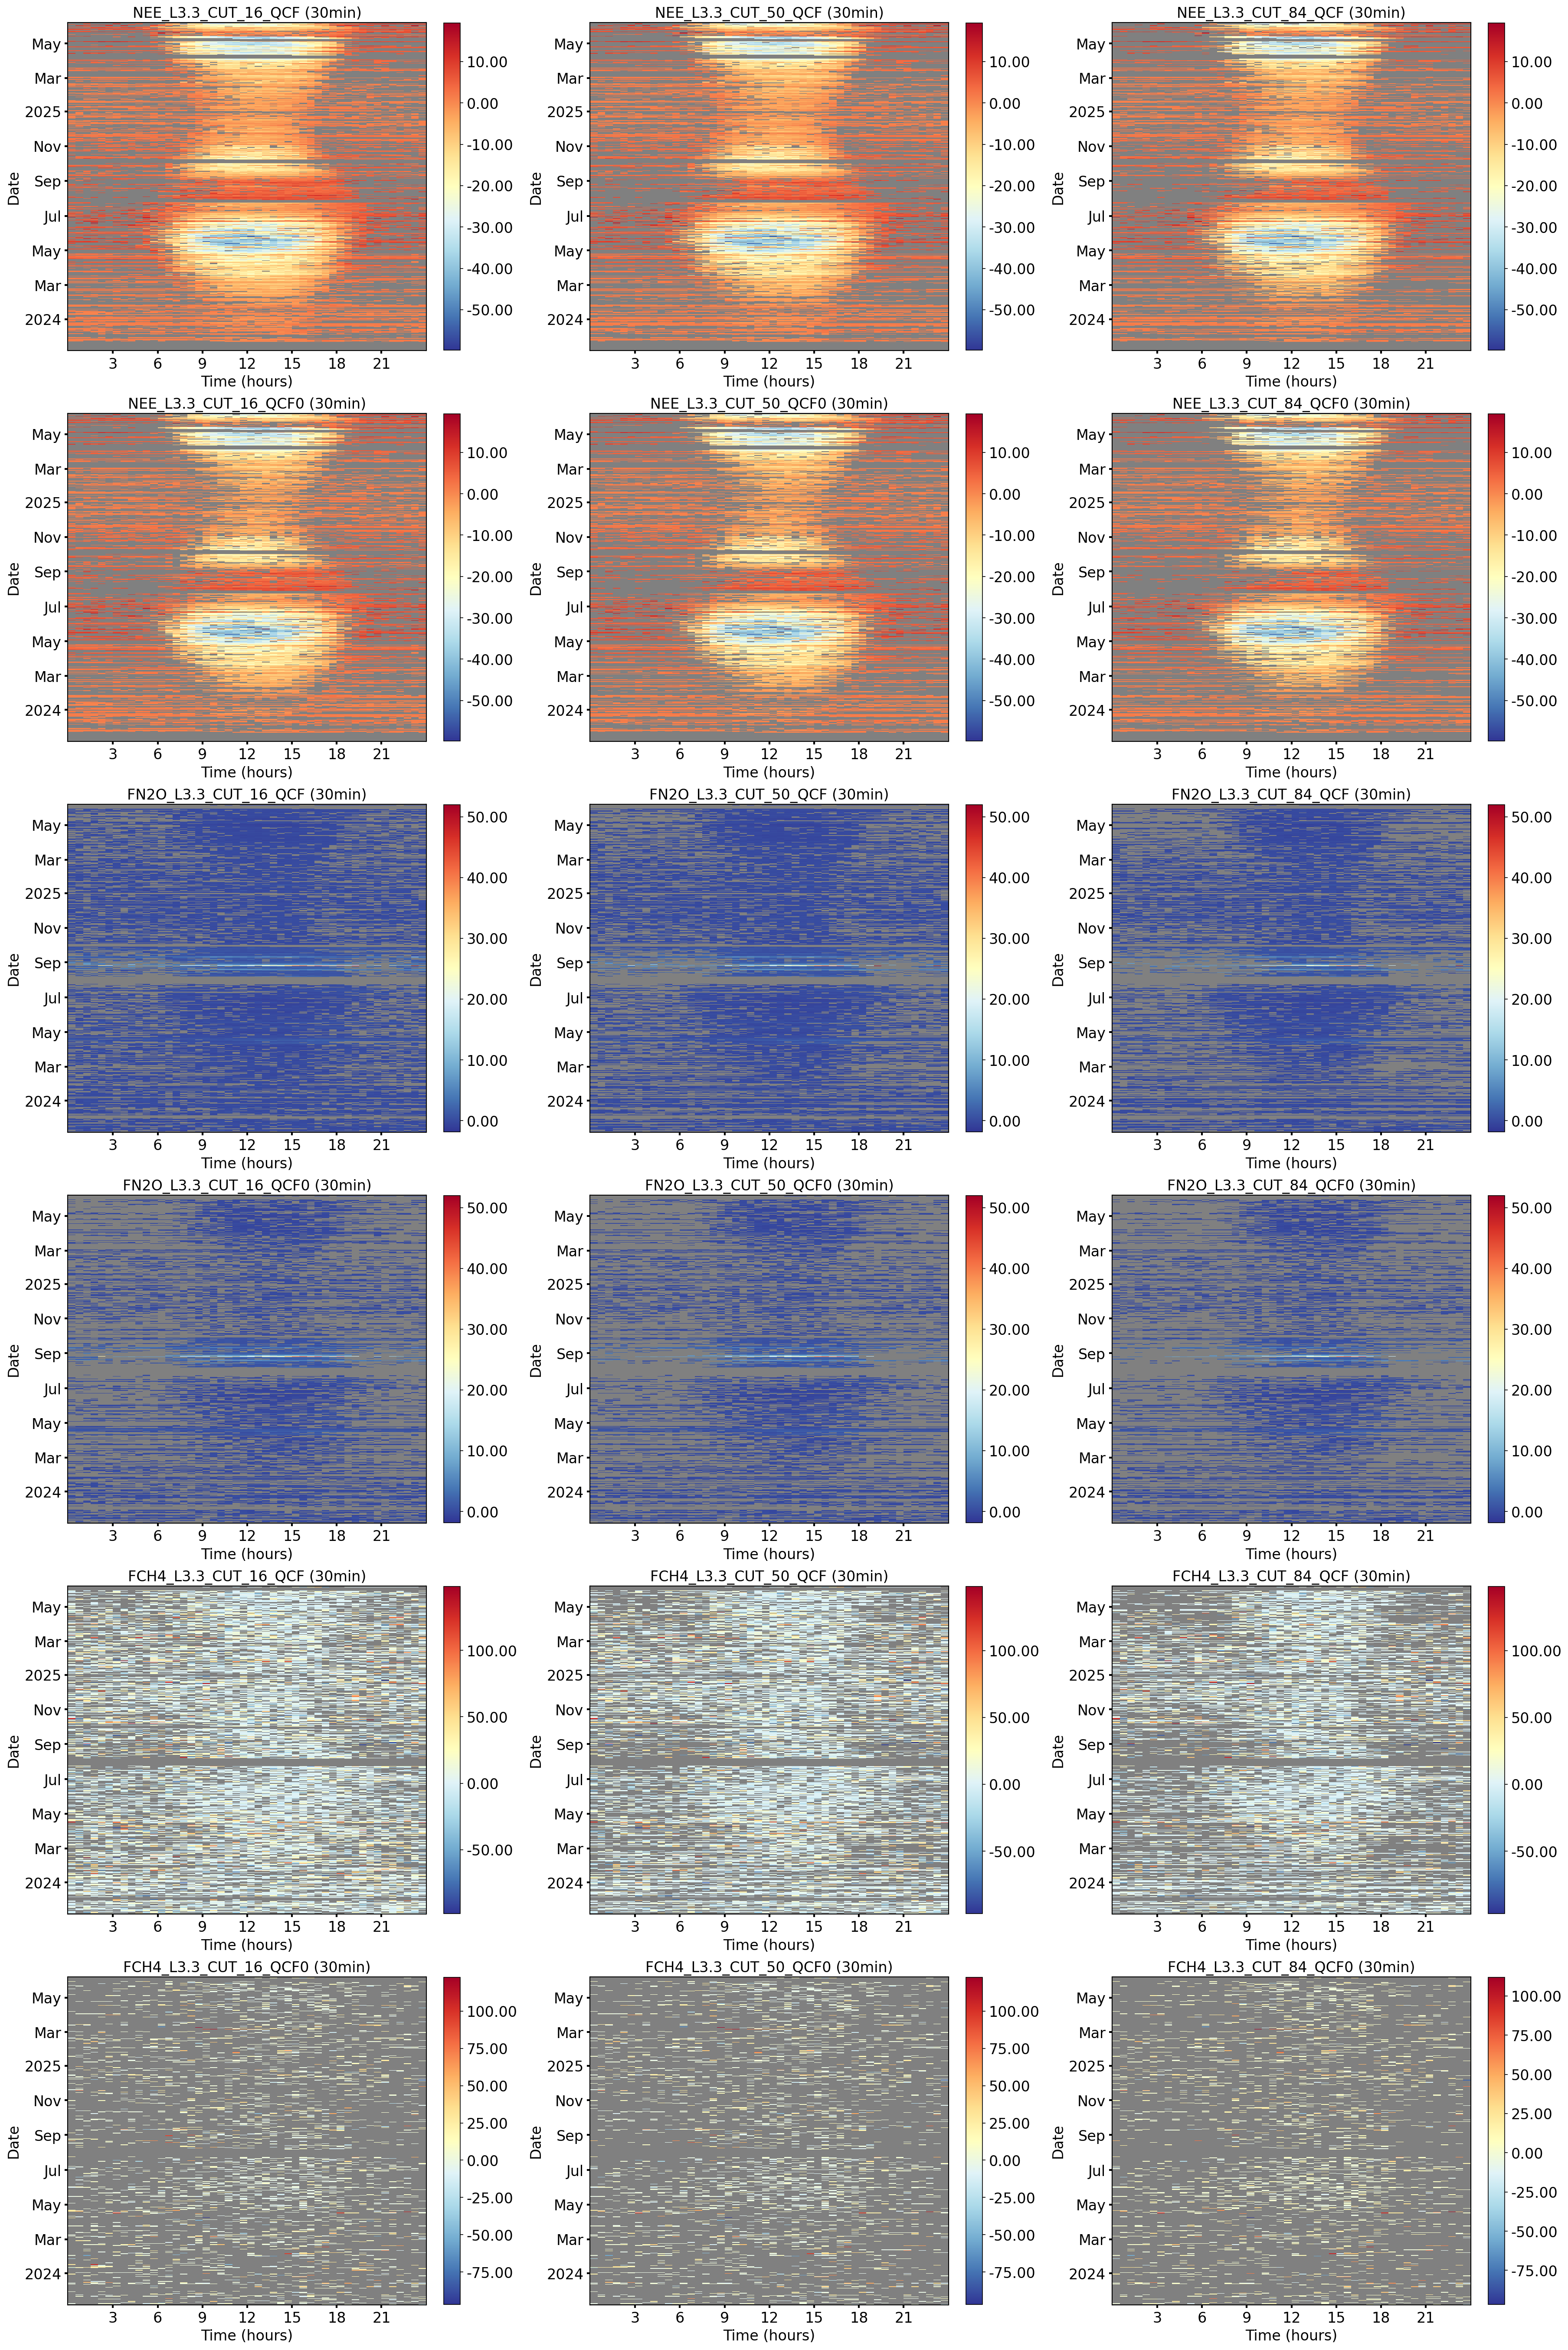

In [10]:
# Plot the ustar-filtered fluxes 
cols_to_plot  = [c for c in df_new.columns if 'CUT' in c and 'TEST' not in c]

fig, axs = plt.subplots(ncols=3, nrows=6, figsize=(24, 36), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, cols_to_plot):
    HeatmapDateTime(series=df_new[var], ax=ax).plot()

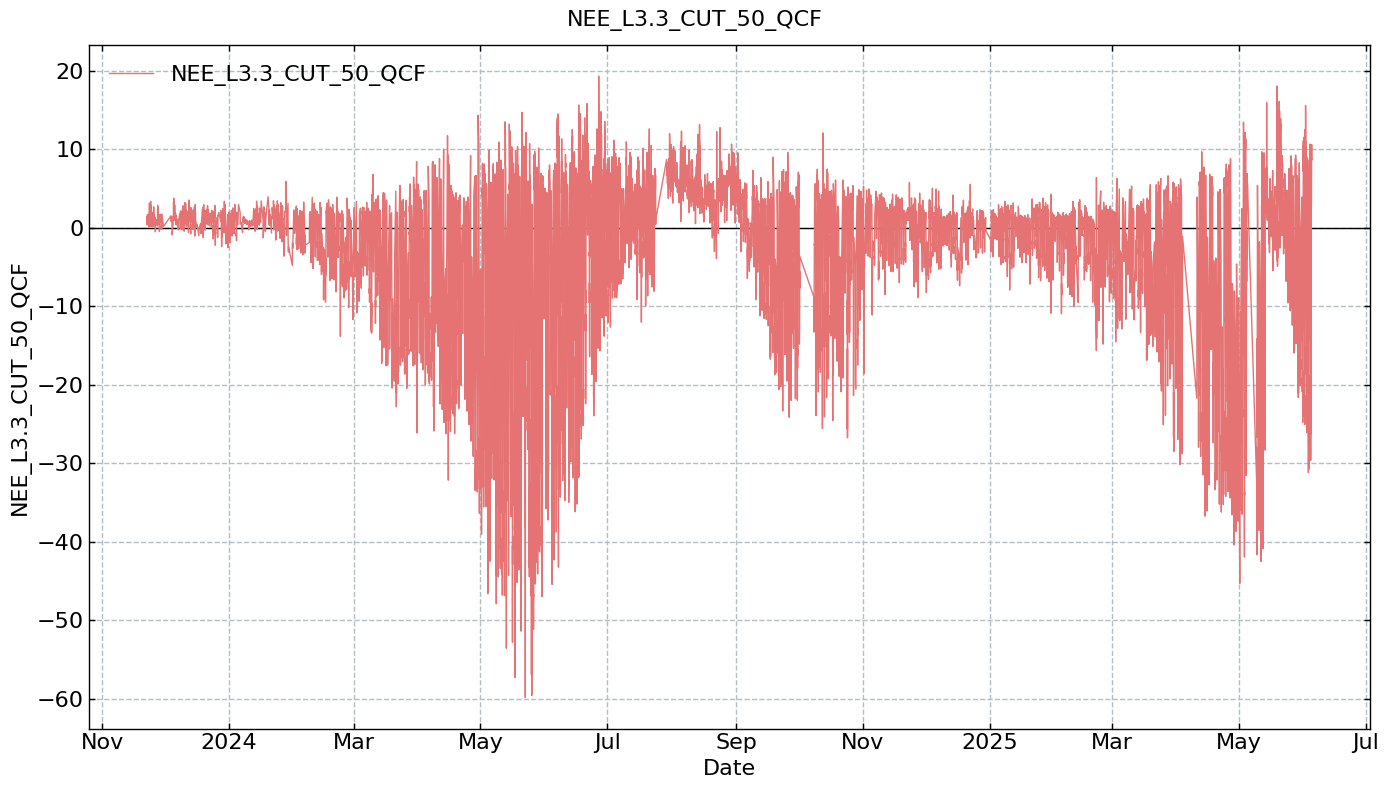

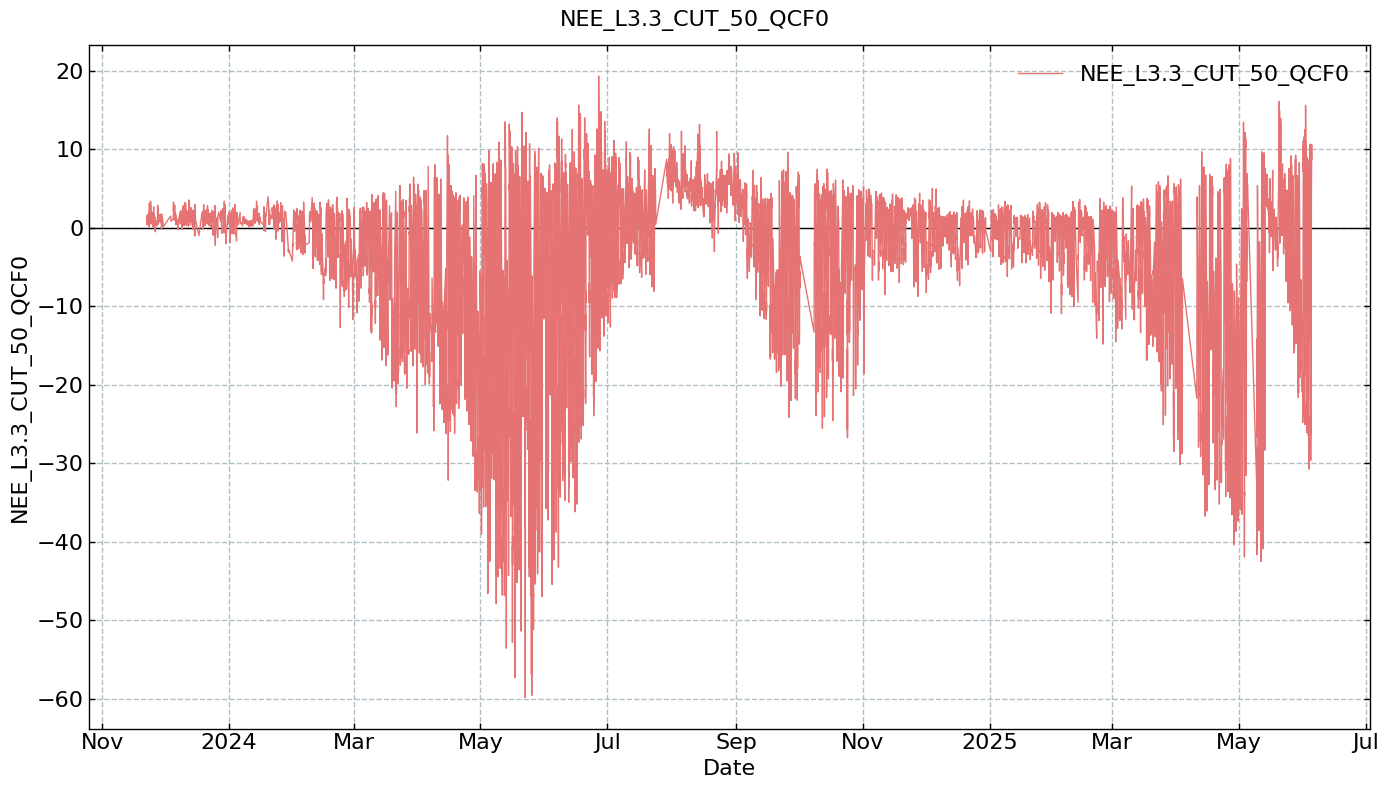

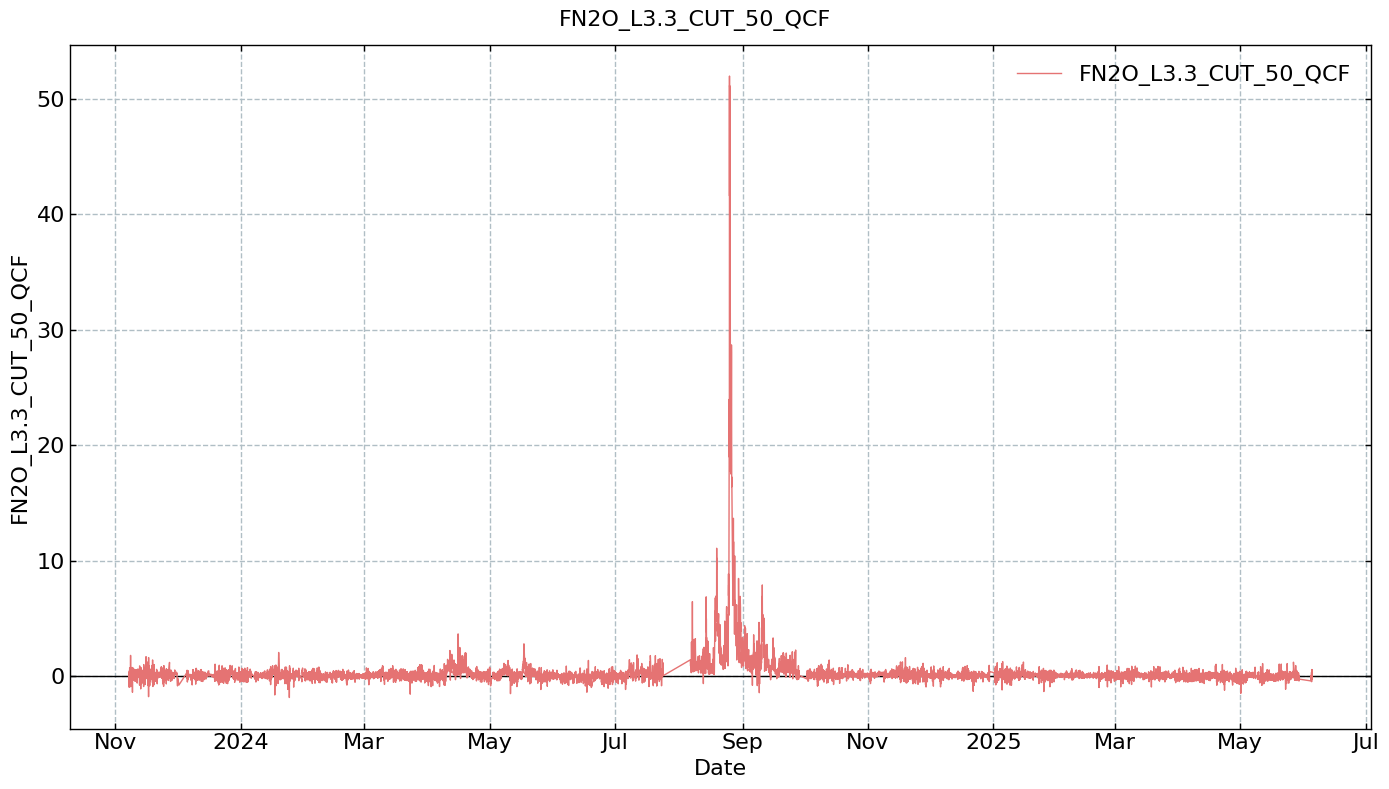

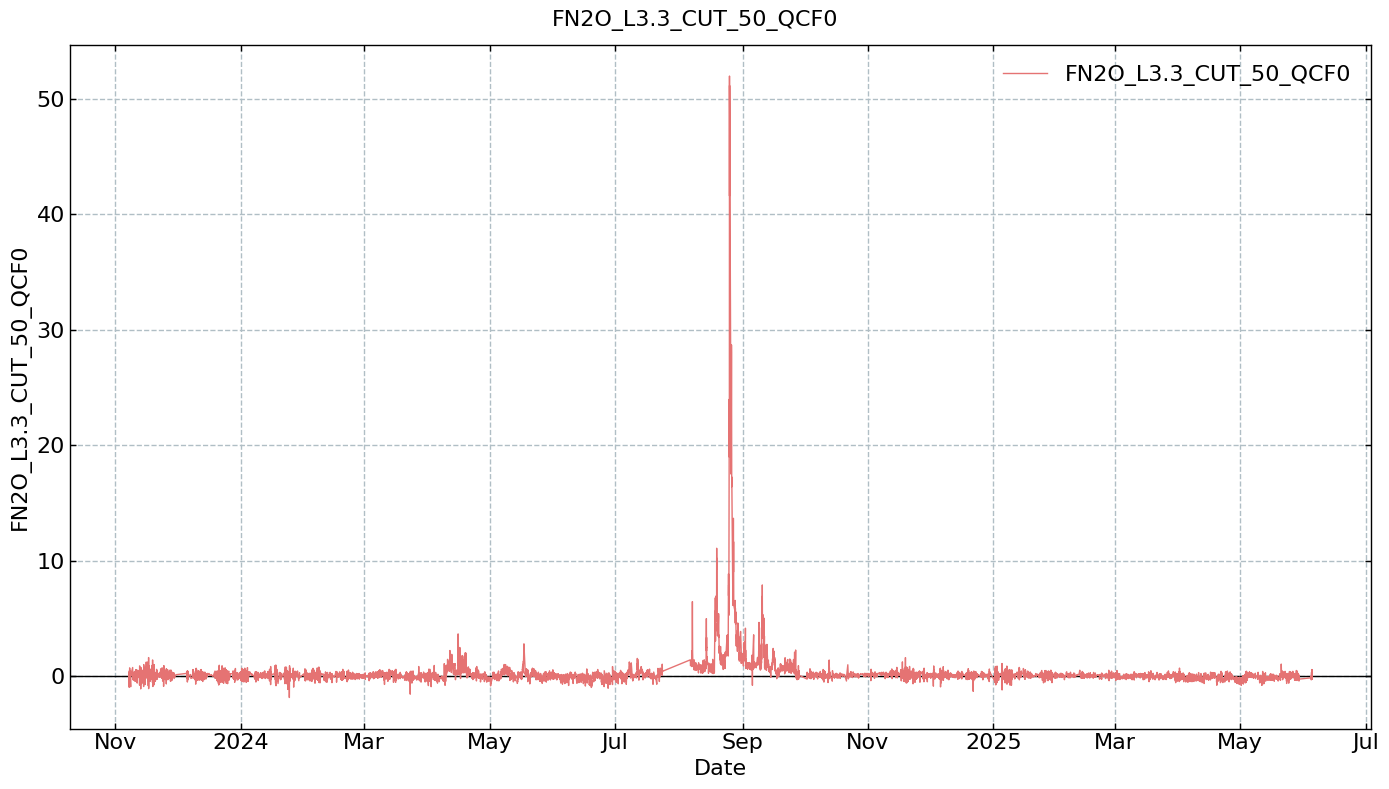

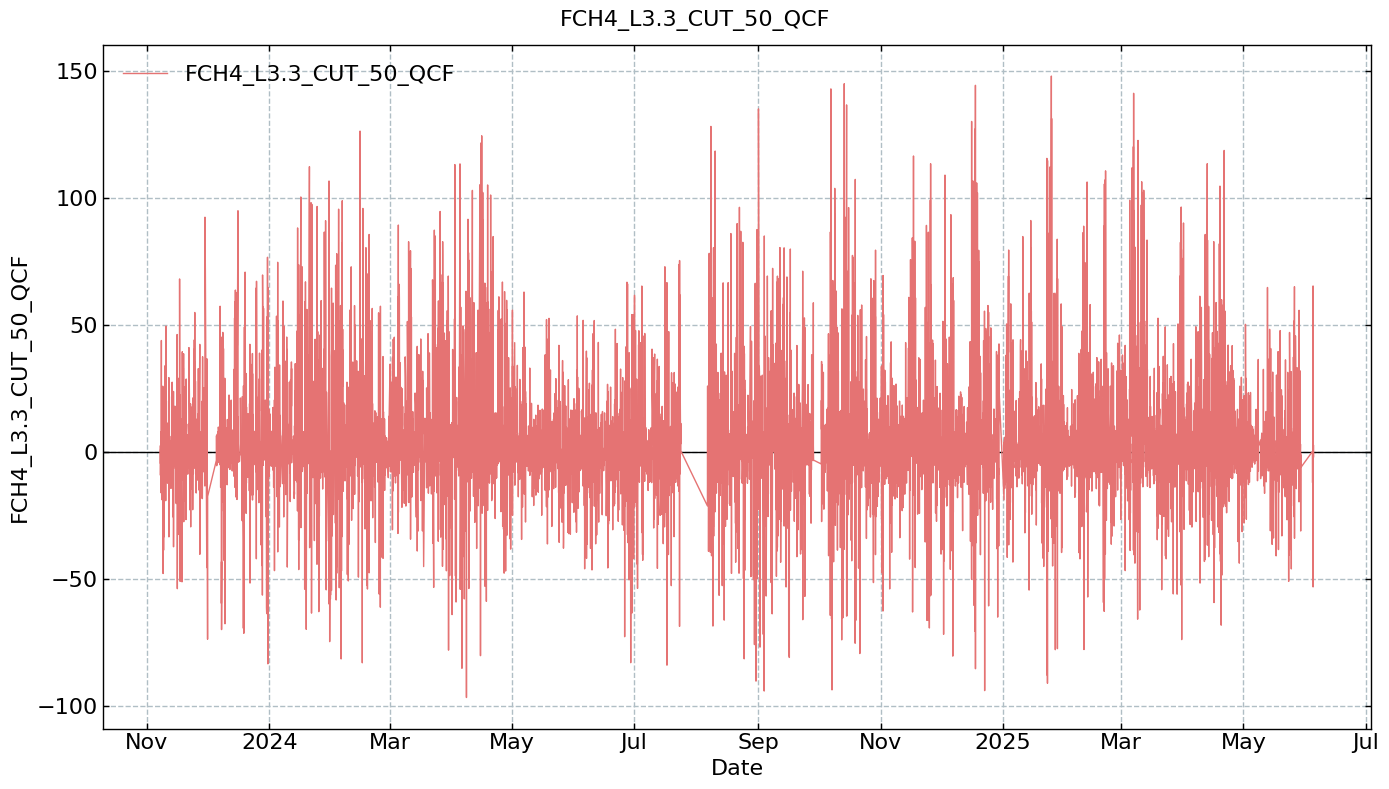

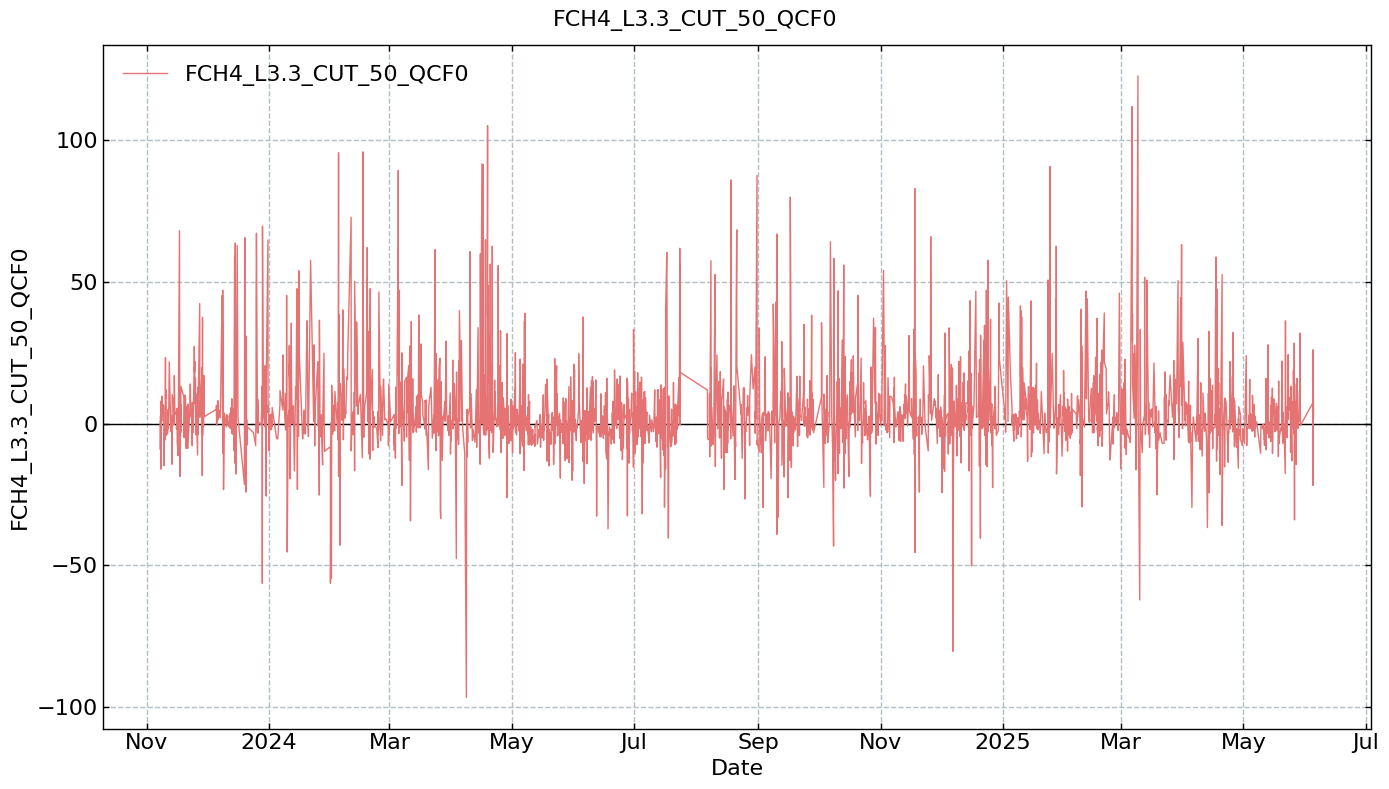

In [11]:
# Plot the variables that will be used in the next steps
for var in [c for c in cols_to_plot if '50' in c]:
    TimeSeries(series=df_new[var]).plot()

</br>

---

# **MERGE**

---

In [12]:
newcols = [c for c in df_new if c not in maindf]
print("NEW VARIABLES FROM USTAR FILTERING:")
[print(f"+ {c}") for c in newcols]
maindf = pd.concat([maindf, df_new[newcols]], axis=1)
maindf

NEW VARIABLES FROM USTAR FILTERING:
+ NEE_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST
+ FCH4_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_84_QCF
+ F

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST,FN2O_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_16_QCF,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_50_QCF,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_84_QCF,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_16_QCF0,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF0_USTAR_TEST
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,1009.65,1.18057,0.024459,1191.96,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-07 16:15:00,1009.74,1.18107,0.024448,1192.57,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,0.324973,0.0,-4.360399,0.0,-4.360399,0.0,-4.360399,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-07 16:45:00,1009.93,1.18176,0.024430,1193.50,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,0.053551,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-07 17:15:00,1009.97,1.18428,0.024377,1196.09,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,0.339963,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0
2023-11-07 17:45:00,1010.06,1.18448,0.024372,1196.40,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,-0.983566,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-0.069384,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0
2025-06-04 23:15:00,1014.04,1.14156,0.025222,1157.59,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-0.288296,0.0,-1.904577,0.0,-1.904577,0.0,-1.904577,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-04 23:45:00,1013.47,1.14369,0.025185,1159.10,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,0.220511,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0


---

# **EXPORT**

---

In [13]:
filename = "62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC"
maindf.to_csv(f"{filename}.csv", index=True)
save_parquet(data=maindf, filename=filename)

Saved file 62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (4.233 seconds).


'62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet'

---

# **End of notebook**

---

In [14]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-10-22 15:41:42
